In [33]:
!pip install boruta catboost xgboost lightgbm optuna -q

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import pickle
import optuna


from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, KFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import TruncatedSVD
from boruta import BorutaPy
from sklearn.feature_selection import SequentialFeatureSelector, RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score, mean_absolute_percentage_error, make_scorer
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb




import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [35]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/resultwithfeatures.csv')

In [36]:
df.head()

,Source,Smiles,Exp. Animal,Method of administration,LD50,LD50 (a.u.),Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,ChEMBL,Br.Br.Cc1cc(-c2ccc(O)cc2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,300.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,ChEMBL,Br.Br.Cc1cc(-c2cccc(O)c2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,ChEMBL,Br.Br.Cc1cc(-c2ccccc2O)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,ChEMBL,Br.CC(C)C(N)C(=O)NNc1nncc(-c2ccc(Cl)cc2)n1.O,mouse,intraperitoneal,178.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
4,ChEMBL,Br.CC(C)N(CCCOc1ccc(N/C(=N\c2ccccc2)c2ccccc2)c...,mouse,intraperitoneal,140.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


## Предобработка данных

Удаляем столбцы и значения, которые точно будут лишними

In [37]:
print(f'Датасет исходный: {df.shape}')

df = df.drop_duplicates(subset = ['Smiles', 'Exp. Animal', 'Method of administration'])


df = df.drop(['Source', 'Smiles',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)'], axis = 1).reset_index(drop = True)


df = df.dropna(subset=['LD50'])

print(f'Датасет после удаления дубликатов, лишних записей и пропусков по таргету: {df.shape}')

Датасет исходный: (114757, 1422)
Датасет после удаления дубликатов, лишних записей и пропусков по таргету: (98512, 1403)


Сокращаем память датасета за счёт оптимизации типов данных.

In [38]:
print(f'Исходный размер памяти до преобразования типов: {df.memory_usage(deep=True).sum() / (1024 * 1024):.2f} МБ')

obj_cols = df.select_dtypes('object').columns
df[obj_cols] = df[obj_cols].astype('category')

fcols = df.select_dtypes('float').columns
icols = df.select_dtypes('integer').columns

df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

fcols = df.select_dtypes('float').columns
icols = df.select_dtypes('integer').columns

df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

print(f'Размер датасета после преобразования типов: {df.memory_usage(deep=True).sum() / (1024 * 1024):.2f} МБ')

Исходный размер памяти до преобразования типов: 1065.77 МБ
Размер датасета после преобразования типов: 194.57 МБ


In [39]:
df['LD50'].describe()

,LD50
count,9.851200e+04
mean,1.616472e+03
std,2.204321e+04
min,0.000000e+00
25%,1.000000e+02
50%,4.000000e+02
75%,1.000007e+03
max,2.500000e+06


In [40]:
Q10 = df['LD50'].quantile(0.10)
Q90 = df['LD50'].quantile(0.90)
IQR = Q90 - Q10

lower_bound = Q10 - 1.5 * IQR
upper_bound = Q90 + 1.5 * IQR

df = df[(df['LD50'] >= lower_bound) & (df['LD50'] <= upper_bound)]
df = df[df['LD50'] != 0]


threshold = 0.996
#удаляем столбцы, где 99.6% значений — это одно уникальное значение
def drop_constant_columns(df, threshold):
    to_drop = []  # Список столбцов для удаления
    for col in df.columns:
        # Рассчитываем долю самого частого значения
        max_freq = df[col].value_counts(normalize=True).max()
        if max_freq >= threshold:
            to_drop.append(col)
    return df.drop(columns=to_drop)

df_cleaned = drop_constant_columns(df, threshold)
df = df_cleaned.dropna()

print(f'Размерность датасета после работы с выбросами: {df.shape}')

Размерность датасета после работы с выбросами: (92494, 1382)


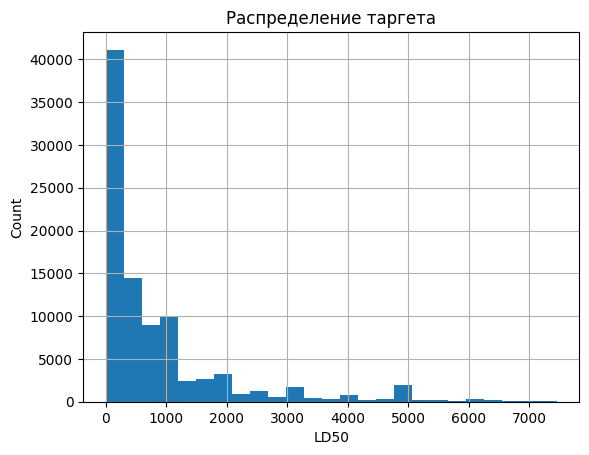

In [41]:
df['LD50'].hist(bins = 25)
plt.title('Распределение таргета')
plt.xlabel('LD50')
plt.ylabel('Count')
plt.show()

Мы видим, что распределение таргета имеет правостороннюю асимметрию. Решение - прологарифмировать, чтобы придать вид нормального распределения.

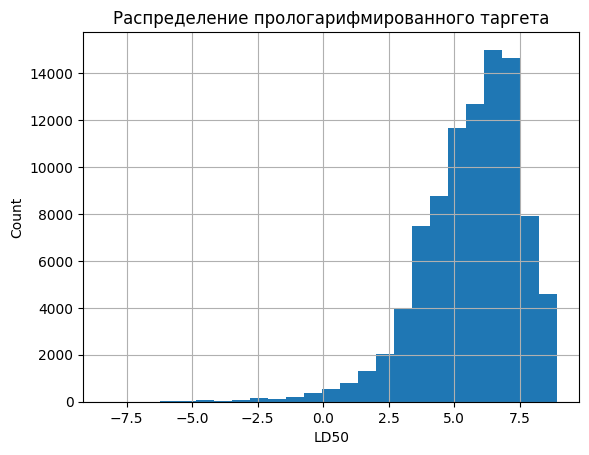

In [42]:
df['log_LD50'] = np.log(df['LD50'] + 1e-9)
df['log_LD50'].hist(bins = 25)
plt.title('Распределение прологарифмированного таргета')
plt.xlabel('LD50')
plt.ylabel('Count')
plt.show()

## Обучение моделей

In [43]:
X = df.drop(columns=['LD50', 'log_LD50'])
y = df['log_LD50']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=123)

In [44]:
num_col = X.select_dtypes(include=['number']).columns.tolist()
cat_col = X.select_dtypes(include=['category']).columns.tolist()

X_train_cat = X_train[cat_col]
X_train_num = X_train[num_col]

X_test_cat = X_test[cat_col]
X_test_num = X_test[num_col]

In [45]:
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = 'first')

X_train_encoded = OHE.fit_transform(X_train_cat)
X_test_encoded = OHE.transform(X_test_cat)

ohe_columns = OHE.get_feature_names_out(cat_col)
X_train_cat = pd.DataFrame(X_train_encoded, columns=ohe_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_encoded, columns=ohe_columns, index=X_test.index)

In [46]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col])
X_test_scaled = scaler.transform(X_test[num_col])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col, index=X_test.index)


X_train = pd.concat([X_train_cat, X_train_scaled], axis=1)
X_test = pd.concat([X_test_cat, X_test_scaled], axis=1)

X_train.shape, X_test.shape

((69370, 1391), (23124, 1391))

План на обучение моделей следующий:

1. Обучение моделей будет базироваться исходя из 3-ёх подходов по отбору признаков:
- SVD (200 признаков)
- SelectKBest (300 признаков)
- Boruta (300 признаков) UPD: метод слишком долгий, не удалось реализовать.


2. В каждом из этих методов будем обучать 3 модели - СatBoost, lightGBM, XGBoost. Проверка качества будет проводиться на кросс-валидации по 3-ём фолдам с минимальным подбором гиперпараметров. Суть данного метода - обнаружить потенциально лучшие по MAPE модели.

3. Тюним лучшую модель с помощью Optuna.


### Обучение моделей на отборе признаков

SVD

In [47]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import TruncatedSVD


svd = TruncatedSVD(n_components=200, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

print(f"Размер X_train до SVD: {X_train.shape}")
print(f"Размер X_train после SVD: {X_train_svd.shape}")
print(f"Размер X_test после SVD: {X_test_svd.shape}")

Размер X_train до SVD: (69370, 1391)
Размер X_train после SVD: (69370, 200)
Размер X_test после SVD: (23124, 200)


In [49]:
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

In [ ]:
param_grid = {
    "max_depth": [20, 40]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=123),
    param_distributions=param_grid,
    n_iter=20,
    scoring=mape_scorer,
    cv=3,
    random_state=123,
    n_jobs=-1
)


random_search.fit(X_train_svd, y_train)
best_params = random_search.best_params_
print(f"Лучшие параметры: {best_params}")


rfr = RandomForestRegressor(random_state=123, **best_params)
rfr.fit(X_train_svd, y_train)


with open('rfr_model_svd.pkl', 'wb') as f:
    pickle.dump(rfr, f)


y_train_pred_log = rfr.predict(X_train_svd)
y_test_pred_log = rfr.predict(X_test_svd)

y_train_pred = np.exp(y_train_pred_log)
y_test_pred = np.exp(y_test_pred_log)


train_mape = mean_absolute_percentage_error(np.exp(y_train), y_train_pred)
test_mape = mean_absolute_percentage_error(np.exp(y_test), y_test_pred)
train_r2 = r2_score(np.exp(y_train), y_train_pred)
test_r2 = r2_score(np.exp(y_test), y_test_pred)

print(f"MAPE на трейне = {train_mape:.4f}")
print(f"MAPE на тесте = {test_mape:.4f}")
print(f"R² на трейне = {train_r2:.4f}")
print(f"R² на тесте = {test_r2:.4f}")

Лучшие параметры: {'max_depth': 40}
MAPE на трейне = 0.4189
MAPE на тесте = 15.6328
R² на трейне = 0.7293
R² на тесте = 0.1979


Как можно заметить - случайный лес сильно переобучается. Возможно стоит более тщательно подбирать гиперпараметры. Воспользуемся более мощными ансамблевыми методами - CatBoost, lightGBM, XGBoost и сравним их качество.

In [ ]:
param_grid_catboost = {
    "iterations": [100, 200],
    "depth": [8, 10, 20],
    "learning_rate": [0.01, 0.1, 0.5]
}

random_search_catboost = RandomizedSearchCV(
    CatBoostRegressor(verbose=False, random_seed=123),
    param_distributions=param_grid_catboost,
    n_iter=20,
    scoring = mape_scorer,
    cv=5,
    random_state=123,
    n_jobs=-1
)


random_search_catboost.fit(X_train_svd, y_train)
best_params_catboost = random_search_catboost.best_params_
print(f"Лучшие параметры CatBoost: {best_params_catboost}")


catboost_svd = CatBoostRegressor(verbose=False, random_seed=123, **best_params_catboost)
catboost_svd.fit(X_train_svd, y_train)

with open('catboost_svd.pkl', 'wb') as f:
    pickle.dump(catboost_svd, f)


y_train_pred_catboost = np.exp(catboost_svd.predict(X_train_svd))
y_test_pred_catboost = np.exp(catboost_svd.predict(X_test_svd))

print(f"MAPE CatBoost на трейне = {mean_absolute_percentage_error(np.exp(y_train), y_train_pred_catboost):.4f}")
print(f"MAPE CatBoost на тесте = {mean_absolute_percentage_error(np.exp(y_test), y_test_pred_catboost):.4f}")
print(f"R² CatBoost на трейне = {r2_score(np.exp(y_train), y_train_pred_catboost):.4f}")
print(f"R² CatBoost на тесте = {r2_score(np.exp(y_test), y_test_pred_catboost):.4f}")

Лучшие параметры CatBoost: {'learning_rate': 0.5, 'iterations': 100, 'depth': 10}
MAPE CatBoost на трейне = 1.0537
MAPE CatBoost на тесте = 6.8048
R² CatBoost на трейне = 0.5196
R² CatBoost на тесте = 0.1773


In [ ]:
param_grid_lgb = {
    "n_estimators": [100, 200],
    "num_leaves": [31, 50, 70]
}

random_search_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=123),
    param_distributions=param_grid_lgb,
    n_iter=20,
    scoring= mape_scorer,
    cv=3,
    random_state=123,
    n_jobs=-1
)

random_search_lgb.fit(X_train_svd, y_train)
best_params_lgb = random_search_lgb.best_params_
print(f"Лучшие параметры LightGBM: {best_params_lgb}")

lgb_svd = lgb.LGBMRegressor(random_state=123, **best_params_lgb)
lgb_svd.fit(X_train_svd, y_train)

with open('lgb_svd.pkl', 'wb') as f:
    pickle.dump(lgb_svd, f)

y_train_pred_lgb = np.exp(lgb_svd.predict(X_train_svd))
y_test_pred_lgb = np.exp(lgb_svd.predict(X_test_svd))

print(f"MAPE LightGBM на трейне = {mean_absolute_percentage_error(np.exp(y_train), y_train_pred_lgb):.4f}")
print(f"MAPE LightGBM на тесте = {mean_absolute_percentage_error(np.exp(y_test), y_test_pred_lgb):.4f}")
print(f"R² LightGBM на трейне = {r2_score(np.exp(y_train), y_train_pred_lgb):.4f}")
print(f"R² LightGBM на тесте = {r2_score(np.exp(y_test), y_test_pred_lgb):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015656 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 69370, number of used features: 200
[LightGBM] [Info] Start training from score 5.626899
Лучшие параметры LightGBM: {'num_leaves': 31, 'n_estimators': 100}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 69370, number of used features: 200
[LightGBM] [Info] Start training from score 5.626899
MAPE LightGBM на трейне = 6.8703
MAPE LightGBM на тесте = 20.9808
R² LightGBM на трейне = 0.1638
R² LightGBM на тесте = 0.1221


In [ ]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7]
}

random_search_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=123),
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring= mape_scorer,
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train_svd, y_train)
best_params_xgb = random_search_xgb.best_params_
print(f"Лучшие параметры XGBoost: {best_params_xgb}")

xgb_svd = xgb.XGBRegressor(random_state=123, **best_params_xgb)
xgb_svd.fit(X_train_svd, y_train)


with open('xgb_svd.pkl', 'wb') as f:
    pickle.dump(xgb_svd, f)

y_train_pred_xgb = np.exp(xgb_svd.predict(X_train_svd))
y_test_pred_xgb = np.exp(xgb_svd.predict(X_test_svd))

print(f"MAPE XGBoost на трейне = {mean_absolute_percentage_error(np.exp(y_train), y_train_pred_xgb):.4f}")
print(f"MAPE XGBoost на тесте = {mean_absolute_percentage_error(np.exp(y_test), y_test_pred_xgb):.4f}")
print(f"R² XGBoost на трейне = {r2_score(np.exp(y_train), y_train_pred_xgb):.4f}")
print(f"R² XGBoost на тесте = {r2_score(np.exp(y_test), y_test_pred_xgb):.4f}")

Лучшие параметры XGBoost: {'n_estimators': 100, 'max_depth': 5}
MAPE XGBoost на трейне = 2.9016
MAPE XGBoost на тесте = 12.7035
R² XGBoost на трейне = 0.3033
R² XGBoost на тесте = 0.2062


SelectKBest

In [16]:
selector = SelectKBest(score_func=f_regression, k=300)
X_train_kbest = selector.fit_transform(X_train, y_train)
X_test_kbest = selector.transform(X_test)

selected_features = selector.get_support(indices=True)
#print("Выбранные признаки:", selected_features)

In [ ]:
param_grid_catboost = {
    "iterations": [100, 200],
    "depth": [4, 6, 8]
}

random_search_catboost = RandomizedSearchCV(
    CatBoostRegressor(verbose=False, random_seed=123),
    param_distributions=param_grid_catboost,
    n_iter=20,
    scoring = mape_scorer,
    cv=3,
    random_state=123,
    n_jobs=-1
)


random_search_catboost.fit(X_train_kbest, y_train)
best_params_catboost = random_search_catboost.best_params_
print(f"Лучшие параметры CatBoost: {best_params_catboost}")


catboost_kbest = CatBoostRegressor(verbose=False, random_seed=123, **best_params_catboost)
catboost_kbest.fit(X_train_kbest, y_train)

with open('catboost_kbest.pkl', 'wb') as f:
    pickle.dump(catboost_kbest, f)


y_train_pred_catboost = np.exp(catboost_kbest.predict(X_train_kbest))
y_test_pred_catboost = np.exp(catboost_kbest.predict(X_test_kbest))

print(f"MAPE CatBoost на трейне = {mean_absolute_percentage_error(np.exp(y_train), y_train_pred_catboost):.4f}")
print(f"MAPE CatBoost на тесте = {mean_absolute_percentage_error(np.exp(y_test), y_test_pred_catboost):.4f}")
print(f"R² CatBoost на трейне = {r2_score(np.exp(y_train), y_train_pred_catboost):.4f}")
print(f"R² CatBoost на тесте = {r2_score(np.exp(y_test), y_test_pred_catboost):.4f}")

Лучшие параметры CatBoost: {'iterations': 100, 'depth': 6}
MAPE CatBoost на трейне = 4.2697
MAPE CatBoost на тесте = 7.1030
R² CatBoost на трейне = 0.3077
R² CatBoost на тесте = 0.2725


In [ ]:
param_grid_lgb = {
    "n_estimators": [100, 200],
    "num_leaves": [31, 50, 70]
}

random_search_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=123),
    param_distributions=param_grid_lgb,
    n_iter=20,
    scoring= mape_scorer,
    cv=3,
    random_state=123,
    n_jobs=-1
)

random_search_lgb.fit(X_train_kbest, y_train)
best_params_lgb = random_search_lgb.best_params_
print(f"Лучшие параметры LightGBM: {best_params_lgb}")

lgb_kbest = lgb.LGBMRegressor(random_state=123, **best_params_lgb)
lgb_kbest.fit(X_train_kbest, y_train)

with open('lgb_kbest.pkl', 'wb') as f:
    pickle.dump(lgb_kbest, f)

y_train_pred_lgb = np.exp(lgb_kbest.predict(X_train_kbest))
y_test_pred_lgb = np.exp(lgb_kbest.predict(X_test_kbest))

print(f"MAPE LightGBM на трейне = {mean_absolute_percentage_error(np.exp(y_train), y_train_pred_lgb):.4f}")
print(f"MAPE LightGBM на тесте = {mean_absolute_percentage_error(np.exp(y_test), y_test_pred_lgb):.4f}")
print(f"R² LightGBM на трейне = {r2_score(np.exp(y_train), y_train_pred_lgb):.4f}")
print(f"R² LightGBM на тесте = {r2_score(np.exp(y_test), y_test_pred_lgb):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030526 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18435
[LightGBM] [Info] Number of data points in the train set: 69370, number of used features: 300
[LightGBM] [Info] Start training from score 5.626899
Лучшие параметры LightGBM: {'num_leaves': 70, 'n_estimators': 200}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18435
[LightGBM] [Info] Number of data points in the train set: 69370, number of used features: 300
[LightGBM] [Info] Start training from score 5.626899
MAPE LightGBM на трейне = 1.7366
MAPE LightGBM на тесте = 4.1241
R² LightGBM на трейне = 0.4843
R² LightGBM на тесте = 0.3773


In [ ]:
param_grid_xgb = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 7]
}

random_search_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=123),
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring= mape_scorer,
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train_kbest, y_train)
best_params_xgb = random_search_xgb.best_params_
print(f"Лучшие параметры XGBoost: {best_params_xgb}")

xgb_kbest = xgb.XGBRegressor(random_state=123, **best_params_xgb)
xgb_kbest.fit(X_train_kbest, y_train)

with open('xgb_kbest.pkl', 'wb') as f:
    pickle.dump(xgb_kbest, f)

y_train_pred_xgb = np.exp(xgb_kbest.predict(X_train_kbest))
y_test_pred_xgb = np.exp(xgb_kbest.predict(X_test_kbest))

print(f"MAPE XGBoost на трейне = {mean_absolute_percentage_error(np.exp(y_train), y_train_pred_xgb):.4f}")
print(f"MAPE XGBoost на тесте = {mean_absolute_percentage_error(np.exp(y_test), y_test_pred_xgb):.4f}")
print(f"R² XGBoost на трейне = {r2_score(np.exp(y_train), y_train_pred_xgb):.4f}")
print(f"R² XGBoost на тесте = {r2_score(np.exp(y_test), y_test_pred_xgb):.4f}")

Лучшие параметры XGBoost: {'n_estimators': 400, 'max_depth': 5}
MAPE XGBoost на трейне = 1.0687
MAPE XGBoost на тесте = 3.6132
R² XGBoost на трейне = 0.5916
R² XGBoost на тесте = 0.3820


Boruta — это алгоритм отбора признаков, который базируется на методе леса случайных деревьев.

Суть алгоритма заключается в том, что копируются признаки,
а затем каждый новый признак заполняется случайным образом, путем перетасовки его значений. На полученной выборке запускается Random Forest.
В целях получения статистически значимых результатов эта процедура повторяется несколько раз, переменные генерируются независимо на каждой итерации.

UPD: данный метод оказался невероятно долгим, было принято решение от него отказаться.

| Отбор признаков | Модель          | Лучшие гиперпараметры                              | MAPE трейна | MAPE теста | R² трейна | R² теста |
|------------------|------------------|---------------------------------------------------|-------------|------------|-----------|----------|
| SVD              | RandomForest      | {'max_depth': 40}                                | 0.4189      | 15.6328    | 0.7293    | 0.1979   |
| SVD              | CatBoost         | {'learning_rate': 0.5, 'iterations': 100, 'depth': 10} | 1.0537      | 6.8048     | 0.5196    | 0.1773   |
| SVD              | LightGBM         | {'num_leaves': 31, 'n_estimators': 100}         | 6.8703      | 20.9808    | 0.1638    | 0.1221   |
| SVD              | XGBoost          | {'n_estimators': 100, 'max_depth': 5}           | 2.9016      | 12.7035    | 0.3033    | 0.2062   |
| SelectKBest      | CatBoost         | {'iterations': 100, 'depth': 6}                   | 4.2697      | 7.1030     | 0.3077    | 0.2725   |
| SelectKBest      | LightGBM         | {'num_leaves': 70, 'n_estimators': 200}         | 1.7366      | 4.1241     | 0.4843    | 0.3773   |
| SelectKBest      | XGBoost          | {'n_estimators': 400, 'max_depth': 5}           | 1.0687      | 3.6132     | 0.5916    | 0.3820   |


Как видно из таблицы, наибольшую устойчивость и точность проявила модель XGBoost на отборе признаков с помощью SelectKBest.

<b> Нюанс </b>

В реализациях выше я использовал RandomSearch, но на маленькой выборке возможных значений гиперпараметров, поэтому фактически данный метод работает как GridSearchCV.

### Тюнинг моделей по каждому отбору признаков

Чтобы CatBoost не переобучался, настроим более детально гиперпараметры модели:
- сделаем больше итерацией
- уменьшим глубину дерева
- коэффициент при регуляризации L2 функции потерь. Значение по умолчанию – 3.
- коэффициент остановки 50 - означает, что если после 50 итераций модель не покажет качество лучш

In [24]:
def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 500),  # Количество деревьев
        "max_depth": trial.suggest_int("max_depth", 2, 16),  # Максимальная глубина деревьев
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),  # Скорость обучения
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),  # Доля данных для каждого дерева
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # Доля признаков для каждого дерева
        "gamma": trial.suggest_float("gamma", 0, 5),  # Минимальное снижение оценки для разбиения
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1, log=True),  # L1-регуляризация
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1, log=True),  # L2-регуляризация
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),  # Минимальная сумма весов в листе
    }
    estimator = xgb.XGBRegressor(verbose=False, random_state=123, **param_grid)
    estimator.fit(X_train_kbest, y_train)
    y_pred = estimator.predict(X_test_kbest)
    return mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)


best_params = study.best_trial.params
final_estimator = xgb.XGBRegressor(verbose=False, random_state=123, **best_params)
final_estimator.fit(X_train_kbest, y_train)

y_train_pred_xgb = final_estimator.predict(X_train_kbest)
y_test_pred_xgb = final_estimator.predict(X_test_kbest)

mape_train = mean_absolute_percentage_error(np.exp(y_train), np.exp(y_train_pred_xgb))
mape_test = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_test_pred_xgb))
r2_train = r2_score(np.exp(y_train), np.exp(y_train_pred_xgb))
r2_test = r2_score(np.exp(y_test), np.exp(y_test_pred_xgb))

print(study.best_trial)

print(f"MAPE XGBoost на трейне = {mape_train:.4f}")
print(f"MAPE XGBoost на тесте = {mape_test:.4f}")
print(f"R² XGBoost на трейне = {r2_train:.4f}")
print(f"R² XGBoost на тесте = {r2_test:.4f}")

[I 2025-03-16 02:32:33,678] A new study created in memory with name: no-name-be832c9f-b9ff-4238-87ea-e17164673350
[I 2025-03-16 02:32:40,916] Trial 0 finished with value: 23.15133332109958 and parameters: {'n_estimators': 328, 'max_depth': 3, 'learning_rate': 0.13283611122972516, 'subsample': 0.8477690199118306, 'colsample_bytree': 0.5039298833074064, 'gamma': 4.657077875494276, 'reg_alpha': 0.04052551489449943, 'reg_lambda': 5.550024067920855e-05, 'min_child_weight': 8}. Best is trial 0 with value: 23.15133332109958.
[I 2025-03-16 02:32:45,148] Trial 1 finished with value: 24.200757284380767 and parameters: {'n_estimators': 270, 'max_depth': 6, 'learning_rate': 0.026761652509591713, 'subsample': 0.5657609815506561, 'colsample_bytree': 0.9748369870269684, 'gamma': 3.8417053439538185, 'reg_alpha': 4.677789460535065e-08, 'reg_lambda': 0.038300293130906195, 'min_child_weight': 6}. Best is trial 0 with value: 23.15133332109958.
[I 2025-03-16 02:32:46,164] Trial 2 finished with value: 38.67

FrozenTrial(number=29, state=1, values=[2.6476439463490684], datetime_start=datetime.datetime(2025, 3, 16, 2, 40, 54, 98322), datetime_complete=datetime.datetime(2025, 3, 16, 2, 41, 2, 801552), params={'n_estimators': 323, 'max_depth': 13, 'learning_rate': 0.1651108290362679, 'subsample': 0.5941557364904071, 'colsample_bytree': 0.6429685318342333, 'gamma': 1.0056487041175513, 'reg_alpha': 0.9899004448626143, 'reg_lambda': 2.1754613026893823e-07, 'min_child_weight': 7}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=500, log=False, low=10, step=1), 'max_depth': IntDistribution(high=16, log=False, low=2, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'gamma': FloatDistribution(high=5.0, log=False, low=0.0, step=None), 'reg_alpha': FloatDis

In [52]:
best_params_xgboost = best_params
print(f"Лучшие гиперпараметры XGBoost после Optuna: {best_params_xgboost}")

Перейдём к подбору гиперпараметров lightGBM.

In [54]:
def objective(trial):
    param_grid = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),  # Листья
        "max_depth": trial.suggest_int("max_depth", -1, 16),  # Глубина деревьев, -1 для отсутствия ограничений
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),  # Скорость обучения
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),  # Количество деревьев
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),  # Минимальная выборка в листьях
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),  # Доля данных для каждого дерева (бейггинг)
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # Доля признаков для каждого дерева
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1, log=True),  # L1-регуляризация
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1, log=True),  # L2-регуляризация
        "verbosity": -1,  # Отключение логов
        "random_state": 123,  # Фиксируем случайность для воспроизводимости
    }


    estimator = lgb.LGBMRegressor(**param_grid)
    estimator.fit(X_train_kbest, y_train, eval_set=[(X_test_kbest, y_test)])


    y_pred = estimator.predict(X_test_kbest, num_iteration=estimator.best_iteration_)
    return mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred))


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)


best_params = study.best_trial.params
final_estimator = lgb.LGBMRegressor(**best_params)
final_estimator.fit(X_train_kbest, y_train, eval_set=[(X_test_kbest, y_test)])


y_train_pred_lgbm = final_estimator.predict(X_train_kbest, num_iteration=final_estimator.best_iteration_)
y_test_pred_lgbm = final_estimator.predict(X_test_kbest, num_iteration=final_estimator.best_iteration_)


mape_train = mean_absolute_percentage_error(np.exp(y_train), np.exp(y_train_pred_lgbm))
mape_test = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_test_pred_lgbm))
r2_train = r2_score(np.exp(y_train), np.exp(y_train_pred_lgbm))
r2_test = r2_score(np.exp(y_test), np.exp(y_test_pred_lgbm))


print(study.best_trial)

print(f"MAPE LightGBM на трейне = {mape_train:.4f}")
print(f"MAPE LightGBM на тесте = {mape_test:.4f}")
print(f"R² LightGBM на трейне = {r2_train:.4f}")
print(f"R² LightGBM на тесте = {r2_test:.4f}")

[I 2025-03-16 03:48:27,956] A new study created in memory with name: no-name-f297fa7a-141e-4493-9d6b-11b0790a9616
[I 2025-03-16 03:48:31,025] Trial 0 finished with value: 16.70771713778561 and parameters: {'num_leaves': 52, 'max_depth': 12, 'learning_rate': 0.05313167120088295, 'n_estimators': 127, 'min_child_samples': 57, 'subsample': 0.8413790260378129, 'colsample_bytree': 0.6220637380817873, 'reg_alpha': 0.4189016305471957, 'reg_lambda': 5.398148703590334e-06}. Best is trial 0 with value: 16.70771713778561.
[I 2025-03-16 03:48:43,370] Trial 1 finished with value: 7.250679364697662 and parameters: {'num_leaves': 50, 'max_depth': 16, 'learning_rate': 0.02771042277971449, 'n_estimators': 560, 'min_child_samples': 68, 'subsample': 0.8048733156862781, 'colsample_bytree': 0.6107253867915111, 'reg_alpha': 0.0037010980332026103, 'reg_lambda': 0.015206149565213298}. Best is trial 1 with value: 7.250679364697662.
[I 2025-03-16 03:48:46,234] Trial 2 finished with value: 34.0342719748404 and pa

FrozenTrial(number=91, state=1, values=[2.7625904673555937], datetime_start=datetime.datetime(2025, 3, 16, 4, 6, 47, 667584), datetime_complete=datetime.datetime(2025, 3, 16, 4, 6, 59, 701659), params={'num_leaves': 128, 'max_depth': 10, 'learning_rate': 0.14917718176701167, 'n_estimators': 670, 'min_child_samples': 61, 'subsample': 0.9598073662610848, 'colsample_bytree': 0.6745789257957056, 'reg_alpha': 3.468372502877484e-05, 'reg_lambda': 0.07300956298661629}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'num_leaves': IntDistribution(high=150, log=False, low=20, step=1), 'max_depth': IntDistribution(high=16, log=False, low=-1, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'min_child_samples': IntDistribution(high=100, log=False, low=5, step=1), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistrib

In [55]:
best_params_lightgbm = best_params
print(f"Лучшие гиперпараметры lightGBM после Optuna: {best_params_lightgbm}")

Лучшие гиперпараметры lightGBM после Optuna: {'num_leaves': 128, 'max_depth': 10, 'learning_rate': 0.14917718176701167, 'n_estimators': 670, 'min_child_samples': 61, 'subsample': 0.9598073662610848, 'colsample_bytree': 0.6745789257957056, 'reg_alpha': 3.468372502877484e-05, 'reg_lambda': 0.07300956298661629}


In [ ]:
lightgbm_best = xgb.XGBRegressor(**best_params_xgboost)

kf = KFold(n_splits=5, shuffle=True, random_state=123)
mape_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    lightgbm_best.fit(X_train, y_train)
    y_pred = lightgbm_best.predict(X_test)


    mape = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred))
    r2 = r2_score(np.exp(y_test), np.exp(y_pred))

    mape_scores.append(mape)
    r2_scores.append(r2)

# Вывод результатов
print(f"Средний MAPE на кросс-валидации: {np.mean(mape_scores):.4f}")
print(f"Средний R² на кросс-валидации: {np.mean(r2_scores):.4f}")

In [59]:
def objective(trial):
    param_grid = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "verbose": 0,
        "random_seed": 123,
    }


    estimator = CatBoostRegressor(**param_grid)
    estimator.fit(X_train_svd, y_train, verbose=0)


    y_pred = estimator.predict(X_test_svd)
    return mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred))


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)


best_params = study.best_trial.params
final_estimator = CatBoostRegressor(**best_params)
final_estimator.fit(X_train_svd, y_train)


y_train_pred_catboost = final_estimator.predict(X_train_svd)
y_test_pred_catboost = final_estimator.predict(X_test_svd)


mape_train = mean_absolute_percentage_error(np.exp(y_train), np.exp(y_train_pred_catboost))
mape_test = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_test_pred_catboost))
r2_train = r2_score(np.exp(y_train), np.exp(y_train_pred_catboost))
r2_test = r2_score(np.exp(y_test), np.exp(y_test_pred_catboost))


print(study.best_trial)

print(f"MAPE CatBoost на трейне = {mape_train:.4f}")
print(f"MAPE CatBoost на тесте = {mape_test:.4f}")
print(f"R² CatBoost на трейне = {r2_train:.4f}")
print(f"R² CatBoost на тесте = {r2_test:.4f}")

[I 2025-03-16 04:13:45,616] A new study created in memory with name: no-name-ac38bfe5-92cd-4e54-bd84-0181c2d2c1fb
[I 2025-03-16 04:13:51,161] Trial 0 finished with value: 162.1405977847376 and parameters: {'iterations': 118, 'depth': 5, 'learning_rate': 0.022711017124850123, 'l2_leaf_reg': 0.024701417606746615, 'bagging_temperature': 7.978046540416614, 'random_strength': 9.894864711532952, 'border_count': 236}. Best is trial 0 with value: 162.1405977847376.
[I 2025-03-16 04:14:36,774] Trial 1 finished with value: 5.6931461834357115 and parameters: {'iterations': 715, 'depth': 9, 'learning_rate': 0.2181839049896143, 'l2_leaf_reg': 0.5324702862818065, 'bagging_temperature': 6.1832728574973, 'random_strength': 4.219013143399253, 'border_count': 214}. Best is trial 1 with value: 5.6931461834357115.
[I 2025-03-16 04:14:41,966] Trial 2 finished with value: 85.02203904874496 and parameters: {'iterations': 112, 'depth': 5, 'learning_rate': 0.06759692403689135, 'l2_leaf_reg': 0.1814323183607355

0:	learn: 1.8134473	total: 29.3ms	remaining: 19.9s
1:	learn: 1.7694303	total: 57.2ms	remaining: 19.4s
2:	learn: 1.7359387	total: 82.5ms	remaining: 18.6s
3:	learn: 1.7067334	total: 107ms	remaining: 18s
4:	learn: 1.6822841	total: 131ms	remaining: 17.7s
5:	learn: 1.6610437	total: 154ms	remaining: 17.4s
6:	learn: 1.6390906	total: 179ms	remaining: 17.3s
7:	learn: 1.6213520	total: 203ms	remaining: 17.1s
8:	learn: 1.6061145	total: 225ms	remaining: 16.8s
9:	learn: 1.5893950	total: 249ms	remaining: 16.7s
10:	learn: 1.5771043	total: 272ms	remaining: 16.6s
11:	learn: 1.5646738	total: 292ms	remaining: 16.3s
12:	learn: 1.5519039	total: 316ms	remaining: 16.2s
13:	learn: 1.5384932	total: 339ms	remaining: 16.1s
14:	learn: 1.5290765	total: 360ms	remaining: 16s
15:	learn: 1.5171301	total: 384ms	remaining: 16s
16:	learn: 1.5064110	total: 406ms	remaining: 15.9s
17:	learn: 1.4972455	total: 429ms	remaining: 15.8s
18:	learn: 1.4889900	total: 453ms	remaining: 15.8s
19:	learn: 1.4816856	total: 473ms	remaining:

In [64]:
best_params_catboost = best_params
print(f"Лучшие гиперпараметры CatBoost после Optuna: {best_params_catboost}")

Лучшие гиперпараметры CatBoost после Optuna: {'iterations': 681, 'depth': 9, 'learning_rate': 0.18203430265116613, 'l2_leaf_reg': 8.830684565961688, 'bagging_temperature': 1.105001891562384, 'random_strength': 0.7226479703915847, 'border_count': 38}


In [ ]:
catboost_best = xgb.XGBRegressor(**best_params_xgboost)

kf = KFold(n_splits=5, shuffle=True, random_state=123)
mape_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    catboost_best.fit(X_train, y_train)
    y_pred = catboost_best.predict(X_test)


    mape = mean_absolute_percentage_error(np.exp(y_test), np.exp(y_pred))
    r2 = r2_score(np.exp(y_test), np.exp(y_pred))

    mape_scores.append(mape)
    r2_scores.append(r2)


print(f"Средний MAPE на кросс-валидации: {np.mean(mape_scores):.4f}")
print(f"Средний R² на кросс-валидации: {np.mean(r2_scores):.4f}")